In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

In [2]:
labels = pd.read_csv("/Users/chinmay/Projects/Galaxy Classification/data/processed/galaxy_labels.csv")

labels.head()

,GalaxyID,Galaxy_Class
0,100008,Spiral
1,100023,Barred Spiral
2,100053,Oval
3,100078,Elliptical
4,100090,Elliptical


In [3]:
IMAGE_DIR = Path("../data/raw/images_training_rev1")

print("Number of Images:", len(list(IMAGE_DIR.glob("*.jpg"))))

Number of Images: 61578


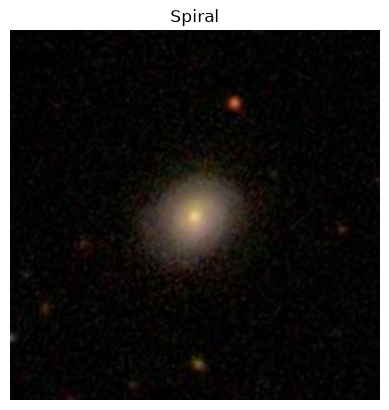

In [4]:
sample = labels.iloc[0]

image_path = IMAGE_DIR / f"{sample['GalaxyID']}.jpg"

img = Image.open(image_path)

plt.imshow(img)
plt.title(sample["Galaxy_Class"])
plt.axis("off")
plt.show()

In [5]:
labels["Galaxy_Class"].unique()

<StringArray>
[        'Spiral',  'Barred Spiral',           'Oval',     'Elliptical',
 'Edge-on Spiral',           'Disk',      'Irregular',    'Ring Galaxy',
         'Merger',          'Cigar',          'Other']
Length: 11, dtype: str

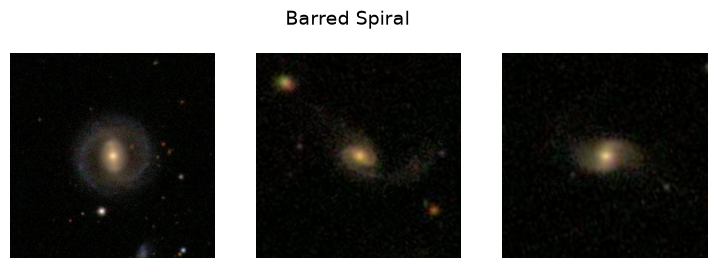

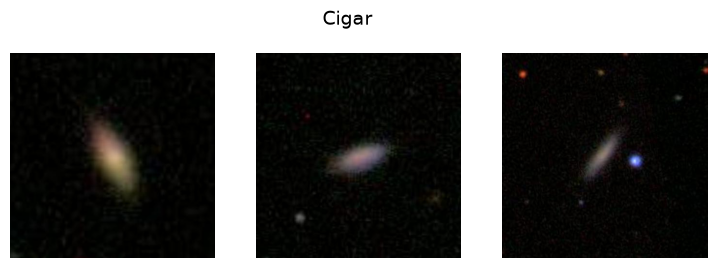

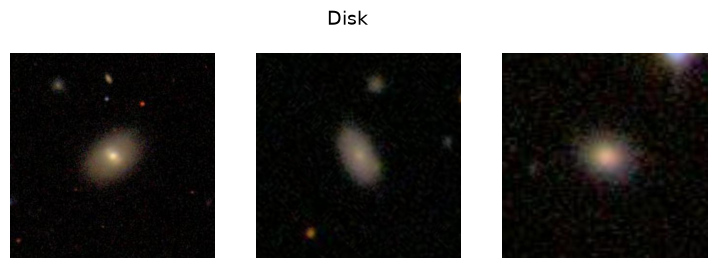

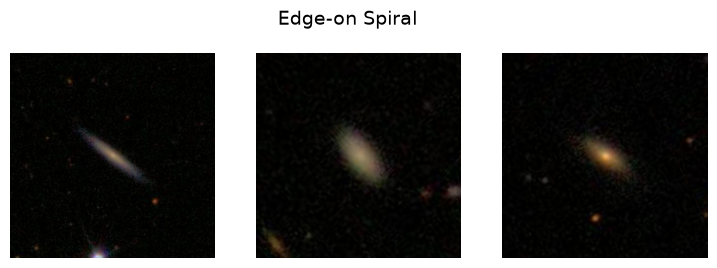

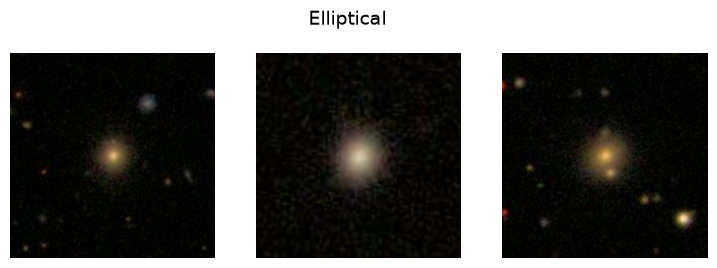

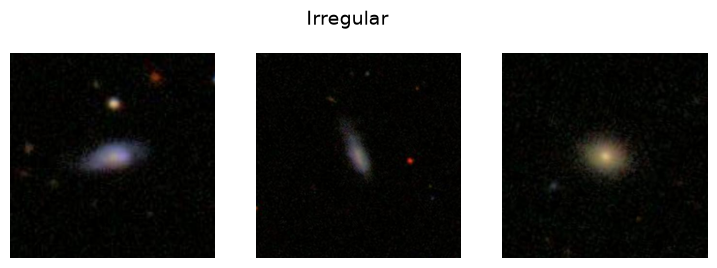

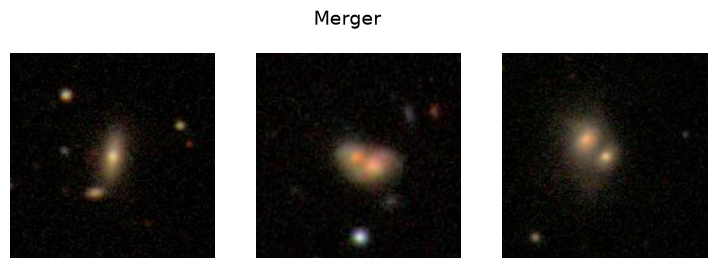

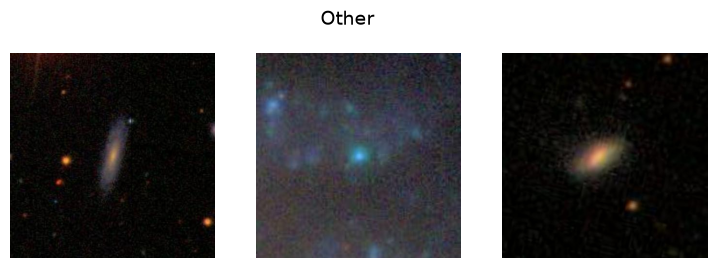

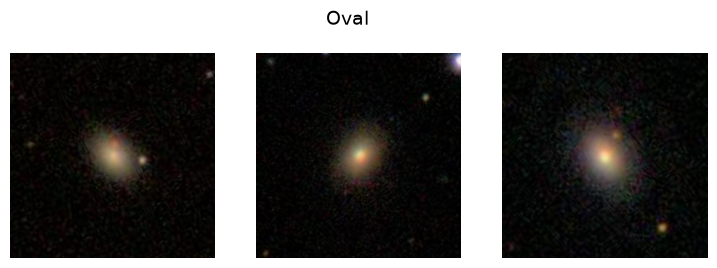

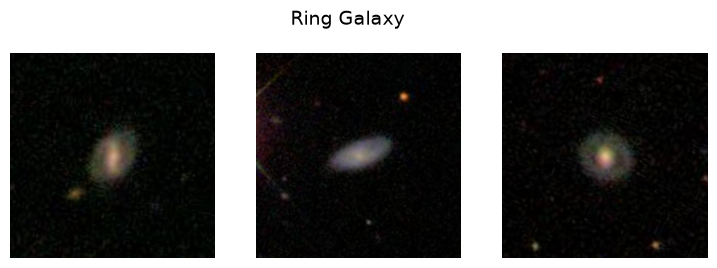

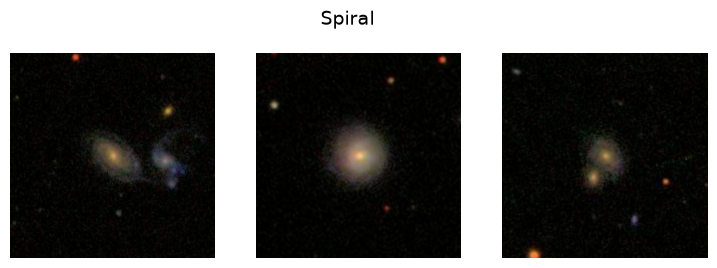

In [6]:
import random

classes = sorted(labels["Galaxy_Class"].unique())

for galaxy_class in classes:

    samples = labels[labels["Galaxy_Class"] == galaxy_class].sample(3, random_state=42)

    plt.figure(figsize=(9,3))
    plt.suptitle(galaxy_class, fontsize=14)

    for i, (_, row) in enumerate(samples.iterrows()):

        img = Image.open(IMAGE_DIR / f"{row['GalaxyID']}.jpg")

        plt.subplot(1,3,i+1)
        plt.imshow(img)
        plt.axis("off")

    plt.show()

In [7]:
from collections import Counter

sizes = Counter()

for img_file in IMAGE_DIR.glob("*.jpg"):
    img = Image.open(img_file)
    sizes[img.size] += 1

sizes


Counter({(424, 424): 61578})